In [1]:

import py4DSTEM
import numpy as np
import torch
import os
import time
import matplotlib.pyplot as plt
from microstructure_inference.dataProcessing import  make_orientation_map_based_on_4D_rotation_matrices
import argparse
import pickle
from microstructure_inference.analysis import soft_disk_loss
import argparse

In [5]:
def remove_direct_beam_and_normalize(py4DSTEM_bragg_disk_object):

    qx = np.copy(py4DSTEM_bragg_disk_object.data["qx"])
    qy = np.copy(py4DSTEM_bragg_disk_object.data["qy"])
    intensity = np.copy(py4DSTEM_bragg_disk_object.data["intensity"])

    k_radial_distnaces_of_BPs = np.linalg.norm(np.stack((qx, qy)).T, axis = 1)
    index_of_direct_beam = np.argmin(k_radial_distnaces_of_BPs)

    qx = np.delete(qx, index_of_direct_beam)
    qy = np.delete(qy, index_of_direct_beam)
    intensity = np.delete(intensity, index_of_direct_beam)
    intensity = intensity / np.max(intensity)

    Bragg_disk_list = np.stack((qx, qy, intensity)).T

    return Bragg_disk_list

def parse_args(args_list=None):
    parser = argparse.ArgumentParser(description="information of scan space dimension and number of crystalline grains")
    parser.add_argument("--accelerating_voltage", type = int, help="accelerating voltage of electron microscopy simulation", default = int(300e3))
    parser.add_argument("--diff_pixel_size", type = float, help="size of pixel of diffraction pattern", default = float(0.0328))
    parser.add_argument("--diff_pixel_numbers", type = int, help="number of pixels in a dimension of diffraction pattern", default = int(128))
    parser.add_argument("--correlationThresholdTemplateMatch", type = int, help="scan space dimension", default = int(14000))
    parser.add_argument("--seed", type = int, help="random number seed for numpy and torch", default = int(22))
    parser.add_argument("--printArg", action="store_true", help="print all arguments")
    parser.add_argument("--trainedTrial", type = str, help="index that indicate independetly trained model", default = str("sing_05"))
    parser.add_argument("--perform_py4DSTEM_orientation_map", action="store_true",help="perform py4DSTEM orientation mapping of given Bragg PointList using ACOM")
    return parser.parse_args(args=args_list)

In [6]:
# To use purely your default arguments:
args = parse_args(args_list=[])

In [7]:
correlationThresholdTemplateMatch = args.correlationThresholdTemplateMatch
accelerating_voltage = int(args.accelerating_voltage)

pixel_size = args.diff_pixel_size
pixel_numbers = args.diff_pixel_numbers

trained_model_indicator_index = args.trainedTrial

k_max = pixel_size * pixel_numbers / 2.

seed = args.seed

start_perf = time.perf_counter()

torch.manual_seed(seed)
np.random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("")
print("torch device:", device, "\n")


model_path = os.getcwd() + "/"
processed_data_saving_path = model_path + "processed_data/"
image_output_path = model_path + "figure_04_panel_a_c/"
file_path = model_path + "../"
Cu_cif = "Cu_fcc.cif"
Bragg_vector_file_name = "bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_%d"%(correlationThresholdTemplateMatch)
# torch_input = torch.load(procssed_data_saving_path + Bragg_vector_file_name + "_table.pt")
prediced_rotation_matrices = np.load(processed_data_saving_path + trained_model_indicator_index + "_" + Bragg_vector_file_name + "_rotation_matrices_canonical.npy")
filepath_braggdisks_cal = file_path + Bragg_vector_file_name + ".h5"
bragg_disks = py4DSTEM.read(filepath_braggdisks_cal)


end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf
print("\n")
print(f"Loading Bragg disk list: {elapsed_perf:.6f} seconds\n\n")



    

table_BPs_scanIndex = {}
dict_idx = 0
for i in range(bragg_disks.shape[0]):
    for j in range(bragg_disks.shape[1]):
        if len(bragg_disks.cal[i,j].qx) > 2:

            qx = np.copy(bragg_disks.cal[i,j].data["qx"])
            qy = np.copy(bragg_disks.cal[i,j].data["qy"])
            intensity = np.copy(bragg_disks.cal[i,j].data["intensity"] / np.max(bragg_disks.cal[i,j].data["intensity"]))

            k_radial_distnaces_of_BPs = np.linalg.norm(np.stack((qx, qy)).T, axis = 1)
            index_of_direct_beam = np.argmin(k_radial_distnaces_of_BPs)

            qx = np.delete(qx, index_of_direct_beam)
            qy = np.delete(qy, index_of_direct_beam)
            intensity = np.delete(intensity, index_of_direct_beam)

            

            positions_of_Bragg_disks = np.stack((qx, qy)).T
            k_radial_distnaces_of_BPs = np.linalg.norm(positions_of_Bragg_disks, axis = 1)
            polar_angles = np.arctan2(positions_of_Bragg_disks[:,1], positions_of_Bragg_disks[:,0])


            table_BPs_scanIndex[dict_idx] = {'input': np.stack((k_radial_distnaces_of_BPs, polar_angles, intensity)).T, 'scanIndices': [i,j]}

            dict_idx += 1
            


crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(file_path + Cu_cif)
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(k_max)

crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = accelerating_voltage,
    # intensity_power = 0.5,
    # corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)

rotation_map_4D = np.zeros((256,150,3,3))

for key, value in table_BPs_scanIndex.items():
    

    i, j = value['scanIndices'][0], value['scanIndices'][1]
    
    rotation_map_4D[i,j] = prediced_rotation_matrices[key]

orientation_map = make_orientation_map_based_on_4D_rotation_matrices(rotation_map_4D, crystal)

images_orientation, fig, ax  = crystal.plot_orientation_maps(
    orientation_map,
    # orientation_ind=0,
    # symmetry_order = 6,
    corr_range = [0.9, 1.0],
    figsize = (9,9),
    returnfig = True,
)

# fig.savefig(image_output_path + trained_model_indicator_index + "_orientation_map_from_transformer_model_cortThForTemp_%d.pdf"%(correlationThresholdTemplateMatch), bbox_inches='tight')
# fig.savefig(image_output_path + trained_model_indicator_index + "_orientation_map_from_transformer_model_cortThForTemp_%d.png"%(correlationThresholdTemplateMatch), bbox_inches='tight')
plt.close(fig)
# plt.show()



# py4DSTEM_orientation_map = crystal.match_orientations(
#                                         bragg_disks,
#                                         )

# py4DSTEM_orientationMapping_pickle_filename = processed_data_saving_path + "orientation_map_from_py4DSTEM_cortThForTemp_%d.pkl"%(correlationThresholdTemplateMatch)

# # # Save the py4DSTEM orientation map object
# # with open(py4DSTEM_orientationMapping_pickle_filename, 'wb') as f:
# #     pickle.dump(py4DSTEM_orientation_map, f)

# images_orientation, fig, ax  = crystal.plot_orientation_maps(
#     orientation_map,
#     # orientation_ind=0,
#     # symmetry_order = 6,
#     corr_range = [0.9, 1.0],
#     figsize = (9,9),
#     returnfig = True,
# )

# images_orientation, fig, ax  = crystal.plot_orientation_maps(
#     py4DSTEM_orientation_map,
#     # orientation_ind=0,
#     # symmetry_order = 6,
#     corr_range = [0.9, 1.0],
#     figsize = (9,9),
#     returnfig = True,
# )

# # fig.savefig(image_output_path + "orientation_map_from_py4DSTEM_cortThForTemp_%d.pdf"%(correlationThresholdTemplateMatch), bbox_inches='tight')
# # fig.savefig(image_output_path + "orientation_map_from_py4DSTEM_cortThForTemp_%d.png"%(correlationThresholdTemplateMatch), bbox_inches='tight')
# plt.close(fig)
# # plt.show()


# print("JOB DONE\n\n")



torch device: cuda 



Reading PointListArray: 100%|███| 38400/38400 [00:02<00:00, 17189.42PointList/s]




Loading Bragg disk list: 2.478510 seconds


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 4987.46 zone axes/s]


In [8]:
py4DSTEM_orientationMapping_pickle_filename = processed_data_saving_path + "orientation_map_from_py4DSTEM_cortThForTemp_%d.pkl"%(correlationThresholdTemplateMatch)

# # Save the py4DSTEM orientation map object
# with open(py4DSTEM_orientationMapping_pickle_filename, 'wb') as f:
#     pickle.dump(py4DSTEM_orientation_map, f)



# Open the file in 'rb' (read-binary) mode and load the object
with open(py4DSTEM_orientationMapping_pickle_filename, 'rb') as f:
    py4DSTEM_orientation_map = pickle.load(f)

In [16]:

range_plot = [k_max, k_max]

excitation_error_thresh = 0.02

overall_loss_for_py4DSTEM = []
overall_loss_for_transformer = []

number_of_disks = []

indices_where_transformer_returns_lower_loss = []

for key, value in table_BPs_scanIndex.items():

    if key < 1e8:
    
    
        i, j = value['scanIndices'][0], value['scanIndices'][1]

        observation = bragg_disks.cal[i,j]

        observation_normalized = remove_direct_beam_and_normalize(observation)
        number_of_disks.append(len(observation_normalized))

        
    
        ## transformer
    
        rotationMatrix_transformer = rotation_map_4D[i,j]

        # print("rotationMatrix_transformer \n", rotationMatrix_transformer)

        ## py4DSTEM

        rotationMatrix_py4DSTEM = py4DSTEM_orientation_map.matrix[i,j][0]
        
        # print("rotationMatrix_transformer\n", rotationMatrix_transformer, "\n")
        # print("rotationMatrix_py4DSTEM\n", rotationMatrix_py4DSTEM, "\n")

        ## simulate kinematic diffraction pattern.

        kinematic_transformer = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotationMatrix_transformer,
                                        sigma_excitation_error = excitation_error_thresh
        )

        kinematic_transformer_normalized = remove_direct_beam_and_normalize(kinematic_transformer)


        kinematic_py4DSTEM = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotationMatrix_py4DSTEM,
                                        sigma_excitation_error = excitation_error_thresh
        )

        kinematic_py4DSTEM_normalized = remove_direct_beam_and_normalize(kinematic_py4DSTEM)

        loss_for_transformer = soft_disk_loss.soft_disk_loss(
                                observation_normalized,
                                kinematic_transformer_normalized,
        )

        overall_loss_for_transformer.append(loss_for_transformer)

        loss_for_py4DSTEM = soft_disk_loss.soft_disk_loss(
                                observation_normalized,
                                kinematic_py4DSTEM_normalized,
        )

        overall_loss_for_py4DSTEM.append(loss_for_py4DSTEM)


        if loss_for_transformer < loss_for_py4DSTEM:
            indices_where_transformer_returns_lower_loss.append(key)

number_of_disks = np.array(number_of_disks)

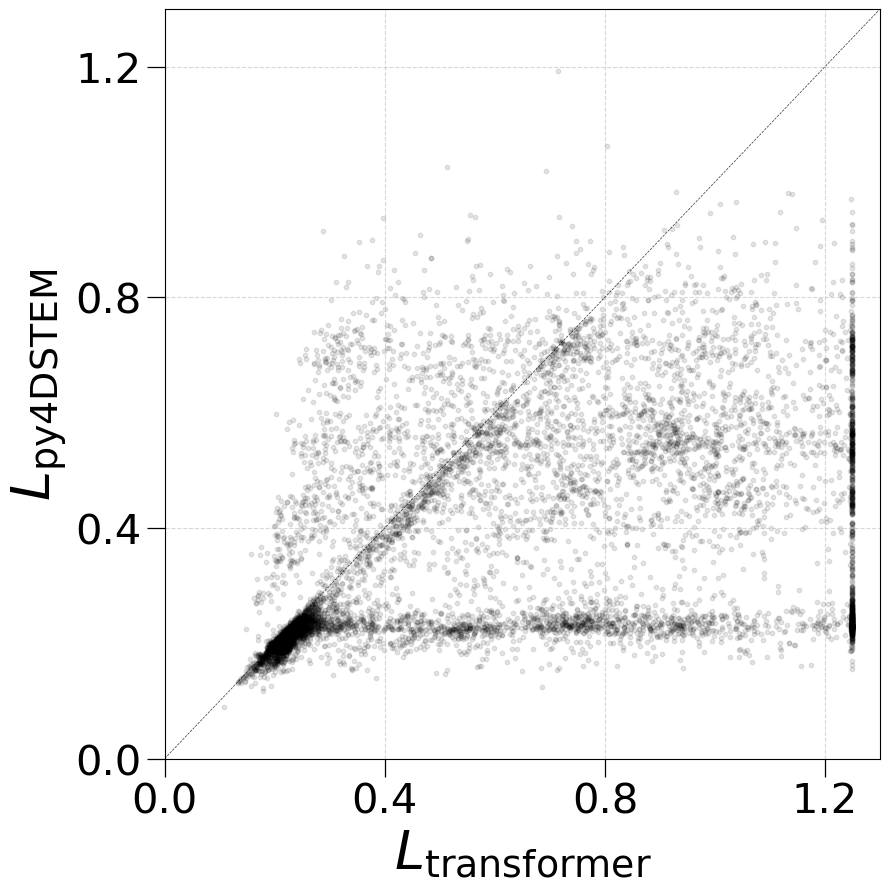

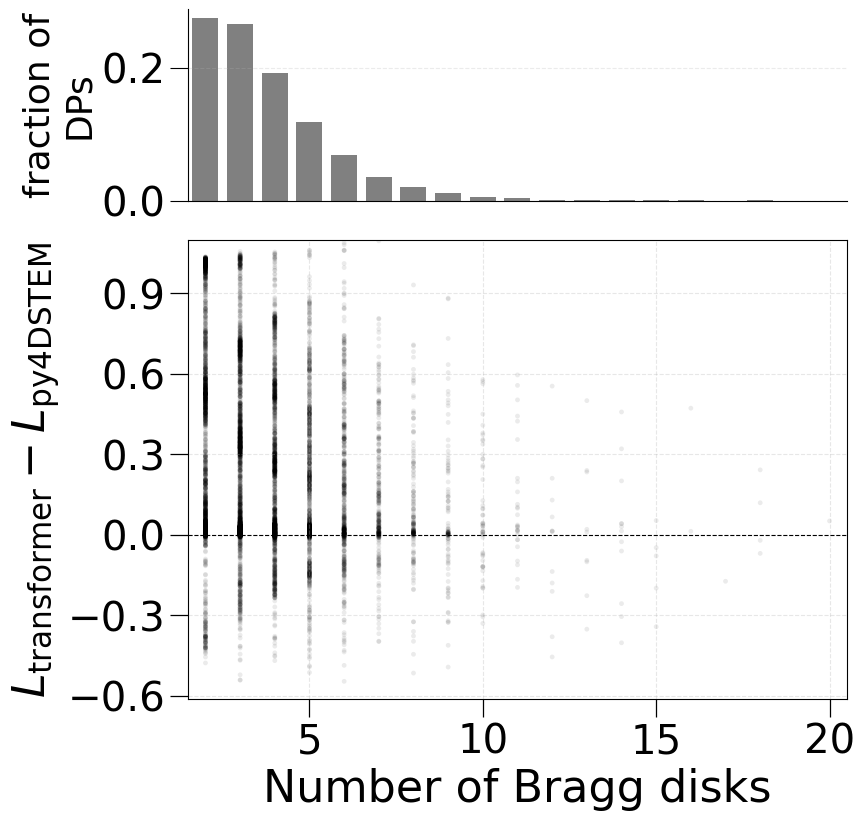

In [17]:
###### Scatter plot (START)
fig, ax = plt.subplots(figsize=(9, 9))

scatter_plot = ax.scatter(overall_loss_for_transformer, overall_loss_for_py4DSTEM, c='#000000', s=10, alpha=0.1, 
                          # rasterized=True,
                         )

ax.set_xlabel(r'$L_{\mathrm{transformer}}$', fontsize=39)
ax.set_ylabel(r'$L_{\mathrm{py4DSTEM}}$', fontsize=39)

# y = x line
lim = 1.3
ax.plot(
    [0, lim],
    [0, lim],
    '--',
    linewidth=0.5,
    color='black',
    alpha=0.8,
)

ax.set_xlim(0, 1.3) 
ax.set_ylim(0, 1.3)

x_ticks = np.array([0.0, 0.4, 0.8, 1.2])
y_ticks = np.array([0.0, 0.4, 0.8, 1.2])
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=30, length=13, width=0.9)

plt.tight_layout()
fig.savefig('loss_comparison_scatter.pdf', format='pdf', bbox_inches='tight', dpi=400)
fig.savefig('loss_comparison_scatter.png', bbox_inches='tight', dpi=400)
plt.show()

###### Scatter plot (END)


################################################################################################
################################################################################################
################################################################################################
################################################################################################

###### Loss difference as a function of Bragg disk number (START)

delta_loss = (
    np.asarray(overall_loss_for_transformer)
    - np.asarray(overall_loss_for_py4DSTEM)
)

number_of_disks = np.asarray(number_of_disks)

# Count observations for each Bragg-disk number
unique_disk_counts, counts = np.unique(
    number_of_disks,
    return_counts=True,
)

fractions = counts / len(number_of_disks)

# ------------------------------------------------------------
# Figure with marginal count plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(8.5, 8.95))

gs = fig.add_gridspec(
    2, 1,
    height_ratios=[2.5, 6],
    hspace=0.12,
)

ax_count = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1], sharex=ax_count)


# ------------------------------------------------------------
# Top: number of observations
# ------------------------------------------------------------
ax_count.bar(
    unique_disk_counts,
    fractions,
    width=0.75,
    color='0.5',
    edgecolor='none',
)

# Log scale because counts range from ~1 to ~2500
# ax_count.set_yscale('log')

# ax_count.set_ylabel(
#     'Fraction of DPs (%)',
#     fontsize=20,
# )

ax_count.set_ylabel(
    'fraction of\nDPs',
    fontsize=26,
    linespacing=1.2,
)

ax_count.tick_params(
    axis='y',
    which='major',
    labelsize=29,
    length=13,
    width=0.8,
)

# Do not show x labels on top panel
ax_count.tick_params(
    axis='x',
    which='both',
    bottom=False,
    labelbottom=False,
)

ax_count.grid(
    True,
    axis='y',
    linestyle='--',
    alpha=0.25,
)

# Remove unnecessary spines
ax_count.spines['right'].set_visible(False)
ax_count.spines['top'].set_visible(False)


# ------------------------------------------------------------
# Bottom: loss difference
# ------------------------------------------------------------
ax.scatter(
    number_of_disks,
    delta_loss,
    s=12,
    alpha=0.08,
    color='black',
    edgecolors='none',
    # rasterized=True,
)

ax.axhline(
    0.0,
    linestyle='--',
    linewidth=0.8,
    color='black',
)

ax.set_xlim(1.5, 20.5)
ax.set_ylim(-0.61, 1.1)

x_ticks = np.array([5, 10, 15, 20])
y_ticks = np.array([-0.6, -0.3, 0.0, 0.3, 0.6, 0.9])

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.set_xlabel(
    'Number of Bragg disks',
    fontsize=32,
)

ax.set_ylabel(
    r'$L_{\mathrm{transformer}} - L_{\mathrm{py4DSTEM}}$',
    fontsize=32,
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.3,
)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=29,
    length=13,
    width=0.9,
)


# plt.tight_layout()

fig.savefig(
    'loss_difference_vs_disks.pdf',
    format='pdf',
    bbox_inches='tight',
    dpi=400,
)

fig.savefig(
    'loss_difference_vs_disks.png',
    bbox_inches='tight',
    dpi=400,
)

plt.show()

###### Loss difference as a function of Bragg disk number (END)

## Transformer a little bit better | py4DSTEM a little bit worse

key 167

#########################################################################


key 167
loss_for_transformer 0.38812094926834106


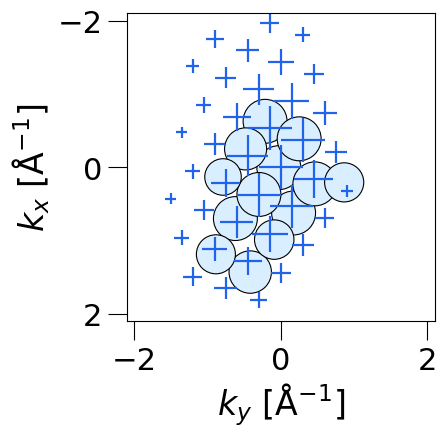

loss_for_py4DSTEM 0.8432248830795288


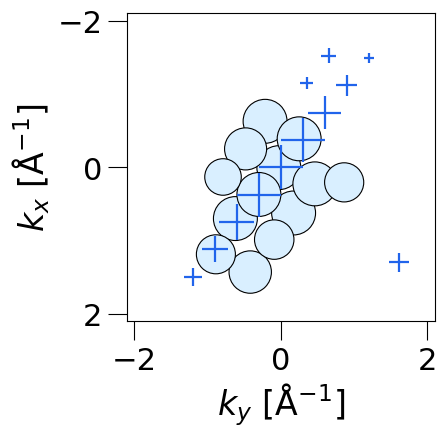

key 631

#########################################################################


key 631
loss_for_transformer 0.5095364451408386


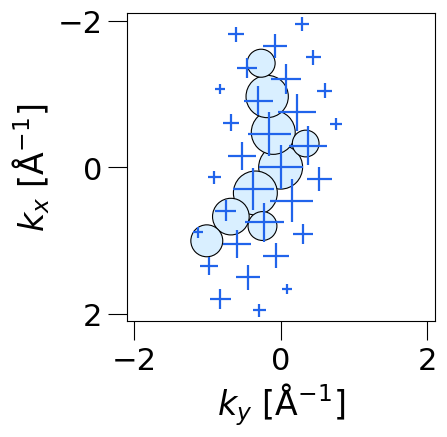

loss_for_py4DSTEM 0.5761613845825195


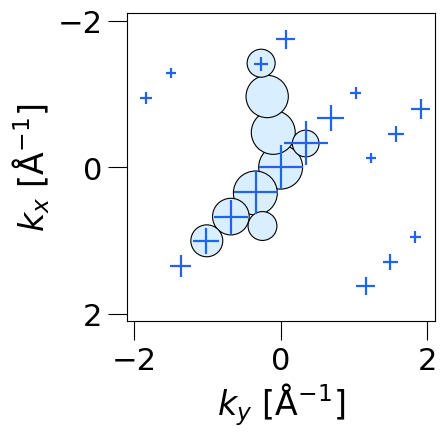

key 2856

#########################################################################


key 2856
loss_for_transformer 0.5515714883804321


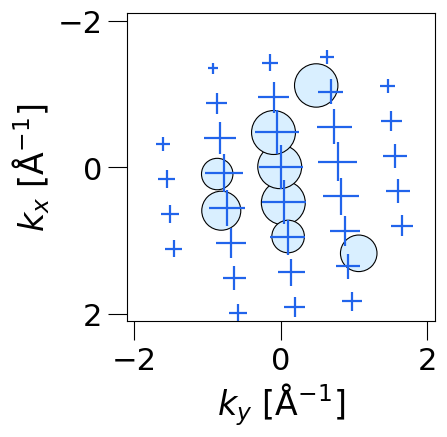

loss_for_py4DSTEM 0.6875500679016113


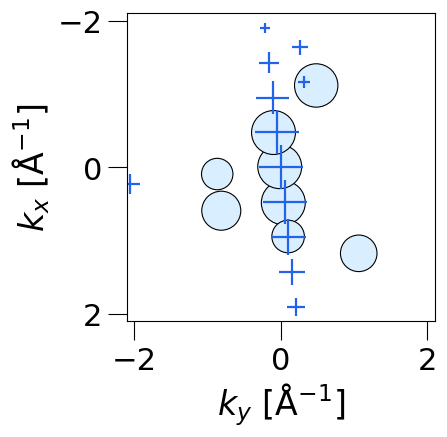

key 5584

#########################################################################


key 5584
loss_for_transformer 0.49046140909194946


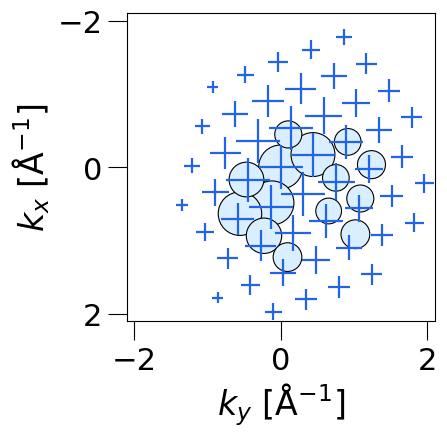

loss_for_py4DSTEM 0.7173253893852234


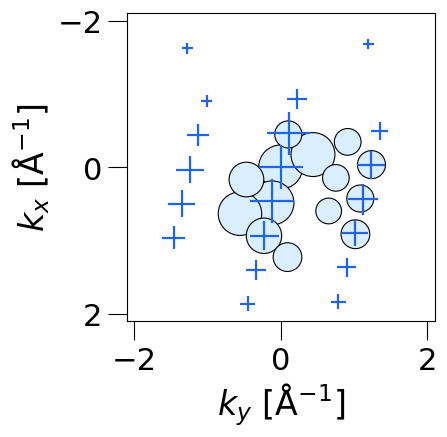

key 5721

#########################################################################


key 5721
loss_for_transformer 0.3534379005432129


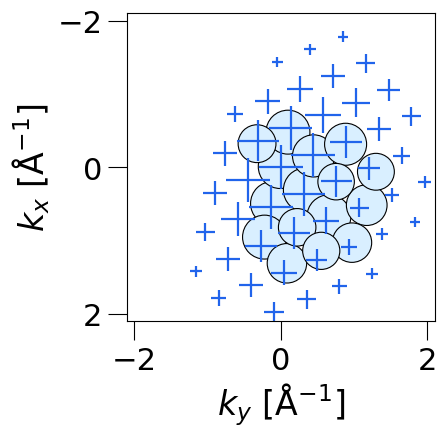

loss_for_py4DSTEM 0.6957913637161255


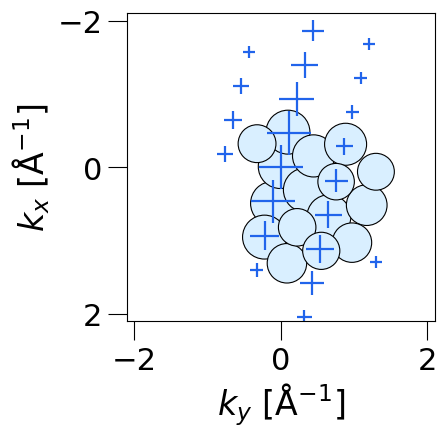

key 7009

#########################################################################


key 7009
loss_for_transformer 0.35145795345306396


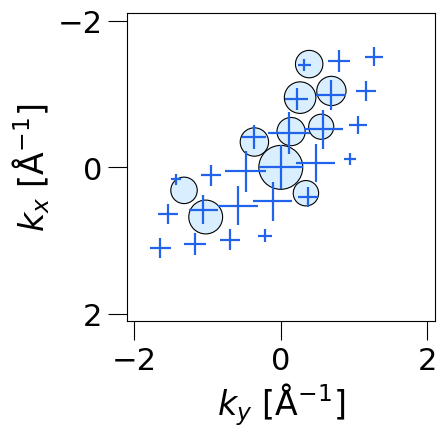

loss_for_py4DSTEM 0.4992889165878296


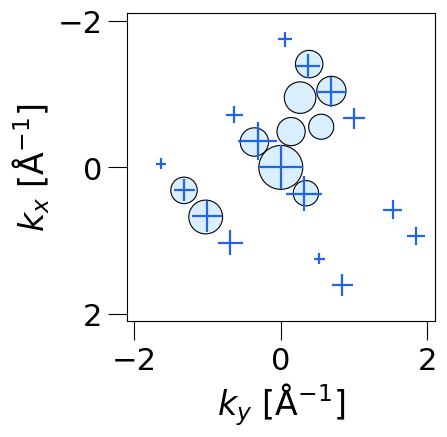

In [14]:


for key, value in table_BPs_scanIndex.items():

    if key in [167, 5584, 5721, 631, 2856, 7009]:

        print("key", key)
    
    
        i, j = value['scanIndices'][0], value['scanIndices'][1]

        observation = bragg_disks.cal[i,j]

        observation_normalized = remove_direct_beam_and_normalize(observation)

        
    
        ## transformer
    
        rotationMatrix_transformer = rotation_map_4D[i,j]

        # print("rotationMatrix_transformer \n", rotationMatrix_transformer)

        ## py4DSTEM

        rotationMatrix_py4DSTEM = py4DSTEM_orientation_map.matrix[i,j][0]
        
        # print("rotationMatrix_transformer\n", rotationMatrix_transformer, "\n")
        # print("rotationMatrix_py4DSTEM\n", rotationMatrix_py4DSTEM, "\n")

        ## simulate kinematic diffraction pattern.

        kinematic_transformer = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotationMatrix_transformer,
                                        sigma_excitation_error = excitation_error_thresh
        )

        kinematic_transformer_normalized = remove_direct_beam_and_normalize(kinematic_transformer)


        kinematic_py4DSTEM = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotationMatrix_py4DSTEM,
                                        sigma_excitation_error = excitation_error_thresh
        )

        kinematic_py4DSTEM_normalized = remove_direct_beam_and_normalize(kinematic_py4DSTEM)

        loss_for_transformer = soft_disk_loss.soft_disk_loss(
                                observation_normalized,
                                kinematic_transformer_normalized,
        )


        loss_for_py4DSTEM = soft_disk_loss.soft_disk_loss(
                                observation_normalized,
                                kinematic_py4DSTEM_normalized,
        )



        if loss_for_transformer < loss_for_py4DSTEM or loss_for_transformer > loss_for_py4DSTEM:



            print("")
            print("#########################################################################\n\n")

            print("key", key)

            print("loss_for_transformer", loss_for_transformer)

    
            fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
                kinematic_transformer,
                bragg_peaks_compare=bragg_disks.cal[i,j],
                scale_markers=5000,
                scale_markers_compare=2000,
                plot_range_kx_ky=range_plot,
                min_marker_size=3,
                figsize = (4,4),
                add_labels = False,
                returnfig = True,
            )
            plt.show()
    
            print("loss_for_py4DSTEM", loss_for_py4DSTEM)
    
            fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
                kinematic_py4DSTEM,
                bragg_peaks_compare=bragg_disks.cal[i,j],
                scale_markers=5000,
                scale_markers_compare=2000,
                plot_range_kx_ky=range_plot,
                min_marker_size=3,
                figsize = (4,4),
                add_labels = False,
                returnfig = True,
            )
            plt.show()

number_of_disks = np.array(number_of_disks)

## transformer worse | py4DSTEM better

key 1040

#########################################################################


key 1040
loss_for_transformer 0.5310812592506409


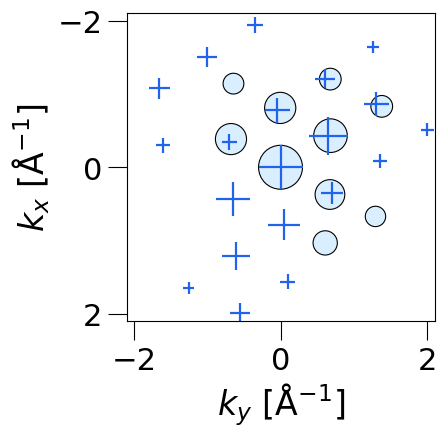

loss_for_py4DSTEM 0.27013444900512695


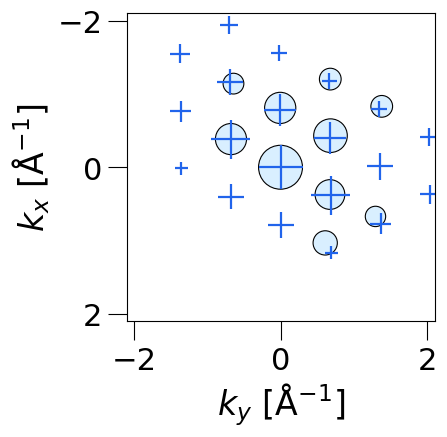

key 1925

#########################################################################


key 1925
loss_for_transformer 1.25


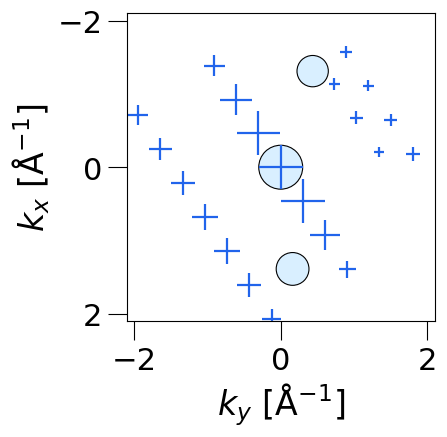

loss_for_py4DSTEM 0.7503693699836731


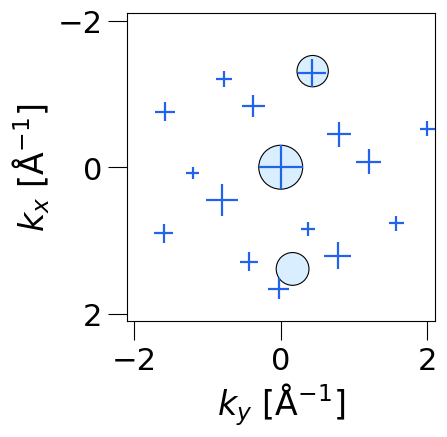

key 4213

#########################################################################


key 4213
loss_for_transformer 1.2499995231628418


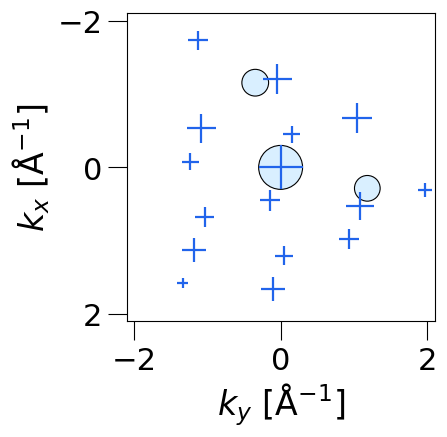

loss_for_py4DSTEM 0.2246185839176178


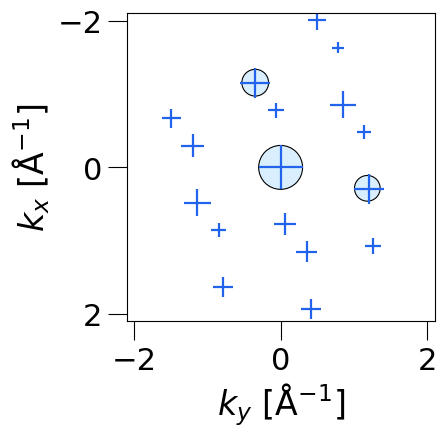

key 7174

#########################################################################


key 7174
loss_for_transformer 1.2499648332595825


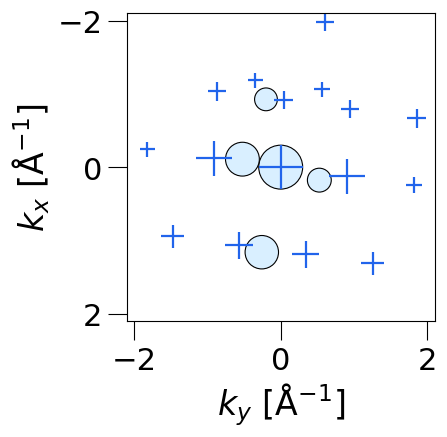

loss_for_py4DSTEM 0.7387229204177856


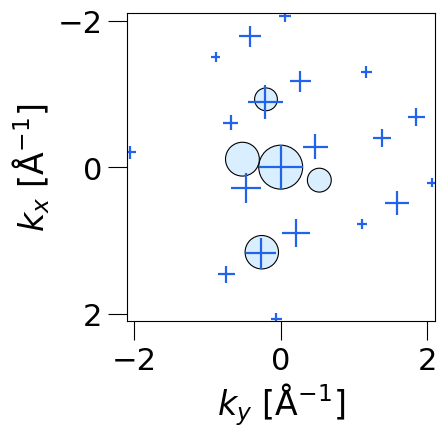

In [15]:


for key, value in table_BPs_scanIndex.items():

    if key in [4213, 7174, 1925, 1040]:

        print("key", key)
    
    
        i, j = value['scanIndices'][0], value['scanIndices'][1]

        observation = bragg_disks.cal[i,j]

        observation_normalized = remove_direct_beam_and_normalize(observation)

        
    
        ## transformer
    
        rotationMatrix_transformer = rotation_map_4D[i,j]

        # print("rotationMatrix_transformer \n", rotationMatrix_transformer)

        ## py4DSTEM

        rotationMatrix_py4DSTEM = py4DSTEM_orientation_map.matrix[i,j][0]
        
        # print("rotationMatrix_transformer\n", rotationMatrix_transformer, "\n")
        # print("rotationMatrix_py4DSTEM\n", rotationMatrix_py4DSTEM, "\n")

        ## simulate kinematic diffraction pattern.

        kinematic_transformer = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotationMatrix_transformer,
                                        sigma_excitation_error = excitation_error_thresh
        )

        kinematic_transformer_normalized = remove_direct_beam_and_normalize(kinematic_transformer)


        kinematic_py4DSTEM = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotationMatrix_py4DSTEM,
                                        sigma_excitation_error = excitation_error_thresh
        )

        kinematic_py4DSTEM_normalized = remove_direct_beam_and_normalize(kinematic_py4DSTEM)

        loss_for_transformer = soft_disk_loss.soft_disk_loss(
                                observation_normalized,
                                kinematic_transformer_normalized,
        )


        loss_for_py4DSTEM = soft_disk_loss.soft_disk_loss(
                                observation_normalized,
                                kinematic_py4DSTEM_normalized,
        )



        if loss_for_transformer < loss_for_py4DSTEM or loss_for_transformer > loss_for_py4DSTEM:



            print("")
            print("#########################################################################\n\n")

            print("key", key)

            print("loss_for_transformer", loss_for_transformer)

    
            fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
                kinematic_transformer,
                bragg_peaks_compare=bragg_disks.cal[i,j],
                scale_markers=5000,
                scale_markers_compare=2000,
                plot_range_kx_ky=range_plot,
                min_marker_size=3,
                figsize = (4,4),
                add_labels = False,
                returnfig = True,
            )
            plt.show()
    
            print("loss_for_py4DSTEM", loss_for_py4DSTEM)
    
            fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
                kinematic_py4DSTEM,
                bragg_peaks_compare=bragg_disks.cal[i,j],
                scale_markers=5000,
                scale_markers_compare=2000,
                plot_range_kx_ky=range_plot,
                min_marker_size=3,
                figsize = (4,4),
                add_labels = False,
                returnfig = True,
            )
            plt.show()

number_of_disks = np.array(number_of_disks)